In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("/mnt/Data2/zfang/rlhf_assignment")
SUMMARY_PATH = PROJECT_ROOT / "outputs" / "pairwise_compare" / "pairwise_results_summary.json"
OUT_DIR = PROJECT_ROOT / "outputs" / "pairwise_compare" / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")

In [2]:
""""helper functions and load summary"""

def wilson_interval(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """95% Wilson score interval for a binomial proportion."""
    if n == 0:
        return 0.0, 0.0

    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half_width = (
        z * math.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2))) / denom
    )
    low = max(0.0, centre - half_width)
    high = min(1.0, centre + half_width)
    return low, high


with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
    summary = json.load(f)

comparisons = summary["comparisons"]
comparisons.keys()

dict_keys(['sft_vs_ppo', 'sft_vs_dpo', 'ppo_vs_dpo'])

In [3]:
"""prepare dataframe for plotting"""

rows = []
for comp_name, comp in comparisons.items():
    valid_n = comp["valid_non_tie_pairs"]
    model_stats = comp["model_stats"]

    for model_name, stats in model_stats.items():
        wins = stats["wins"]
        losses = stats["losses"]
        ties = stats["ties"]
        invalid = stats["invalid"]

        rate = wins / valid_n if valid_n > 0 else 0.0
        ci_low, ci_high = wilson_interval(wins, valid_n)

        rows.append(
            {
                "comparison": comp_name,
                "model": model_name,
                "wins": wins,
                "losses": losses,
                "ties": ties,
                "invalid": invalid,
                "valid_non_tie_pairs": valid_n,
                "win_rate": rate,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

df = pd.DataFrame(rows)

comparison_order = list(comparisons.keys())
model_order = ["sft", "ppo_hh", "dpo_hh"]

df["comparison"] = pd.Categorical(df["comparison"], categories=comparison_order, ordered=True)
df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df = df.sort_values(["comparison", "model"]).reset_index(drop=True)

df

,comparison,model,wins,losses,ties,invalid,valid_non_tie_pairs,win_rate,ci_low,ci_high
0,sft_vs_ppo,sft,3,4,1,2,7,0.428571,0.158217,0.749546
1,sft_vs_ppo,ppo_hh,4,3,1,2,7,0.571429,0.250454,0.841783
2,sft_vs_dpo,sft,6,0,2,2,6,1.000000,0.609657,1.000000
3,sft_vs_dpo,dpo_hh,0,6,2,2,6,0.000000,0.000000,0.390343
4,ppo_vs_dpo,ppo_hh,6,0,1,3,6,1.000000,0.609657,1.000000
5,ppo_vs_dpo,dpo_hh,0,6,1,3,6,0.000000,0.000000,0.390343


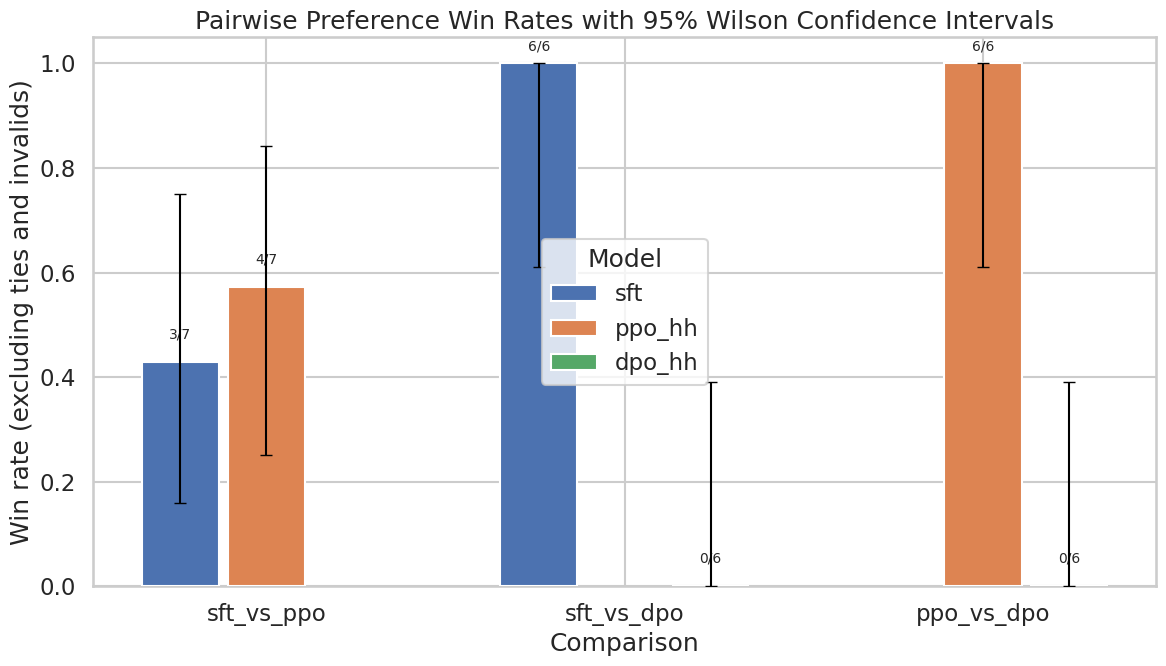

'"Save the figure'

In [4]:
"""Plot 1: win rates with 95% Wilson confidence intervals"""

palette = sns.color_palette("deep", n_colors=len(model_order))
color_map = dict(zip(model_order, palette))

fig, ax = plt.subplots(figsize=(12, 7))

group_centers = list(range(len(comparison_order)))
bar_width = 0.24

offsets = {
    "sft": -bar_width,
    "ppo_hh": 0.0,
    "dpo_hh": bar_width,
}

plotted_labels = set()

for _, row in df.iterrows():
    comp_idx = comparison_order.index(row["comparison"])
    model = row["model"]

    if model not in offsets:
        continue

    x = group_centers[comp_idx] + offsets[model]
    y = float(row["win_rate"])

    color = color_map.get(model, "gray")
    label = model if model not in plotted_labels else None

    ax.bar(
        x,
        y,
        width=bar_width * 0.9,
        color=color,
        label=label,
        zorder=3,
    )

    if label is not None:
        plotted_labels.add(model)

    yerr_low = max(0.0, y - float(row["ci_low"]))
    yerr_high = max(0.0, float(row["ci_high"]) - y)

    ax.errorbar(
        x=x,
        y=y,
        yerr=[[yerr_low], [yerr_high]],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=4,
        zorder=4,
    )

    ax.text(
        x,
        min(y + 0.04, 1.02),
        f"{int(row['wins'])}/{int(row['valid_non_tie_pairs'])}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Pairwise Preference Win Rates with 95% Wilson Confidence Intervals")
ax.set_xlabel("Comparison")
ax.set_ylabel("Win rate (excluding ties and invalids)")
ax.set_xticks(group_centers)
ax.set_xticklabels(comparison_order)
ax.set_ylim(0, 1.05)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(title="Model", frameon=True)

fig.tight_layout()
plt.show()

""""Save the figure"""
# fig.savefig(OUT_DIR / "pairwise_win_rates_wilson_ci.png", dpi=300, bbox_inches="tight")
# fig.savefig(OUT_DIR / "pairwise_win_rates_wilson_ci.pdf", bbox_inches="tight")
# print(OUT_DIR / "pairwise_win_rates_wilson_ci.png")
# print(OUT_DIR / "pairwise_win_rates_wilson_ci.pdf")

In [5]:
"""Plot 2: outcome composition"""
comp_rows = []
for comp_name, comp in comparisons.items():
    model_stats = comp["model_stats"]
    models = list(model_stats.keys())

    if len(models) != 2:
        continue

    m1, m2 = models[0], models[1]

    comp_rows.extend([
        {"comparison": comp_name, "outcome": f"{m1} wins", "count": model_stats[m1]["wins"]},
        {"comparison": comp_name, "outcome": f"{m2} wins", "count": model_stats[m2]["wins"]},
        {"comparison": comp_name, "outcome": "ties", "count": comp["ties"]},
        {"comparison": comp_name, "outcome": "invalid", "count": comp["invalid"]},
    ])

comp_df = pd.DataFrame(comp_rows)

comp_df["comparison"] = pd.Categorical(
    comp_df["comparison"],
    categories=comparison_order,
    ordered=True,
)

pivot_df = (
    comp_df.pivot(index="comparison", columns="outcome", values="count")
    .fillna(0)
    .astype(int)
)

ordered_cols = []
for comp_name in comparison_order:
    if comp_name not in pivot_df.index:
        continue
    for col in pivot_df.columns:
        if col.endswith("wins") and col not in ordered_cols:
            ordered_cols.append(col)
for extra in ["ties", "invalid"]:
    if extra in pivot_df.columns and extra not in ordered_cols:
        ordered_cols.append(extra)

pivot_df = pivot_df[ordered_cols]
pivot_df


outcome,dpo_hh wins,ppo_hh wins,sft wins,ties,invalid
comparison,,,,,
sft_vs_ppo,0,4,3,1,2
sft_vs_dpo,0,0,6,2,2
ppo_vs_dpo,0,6,0,1,3


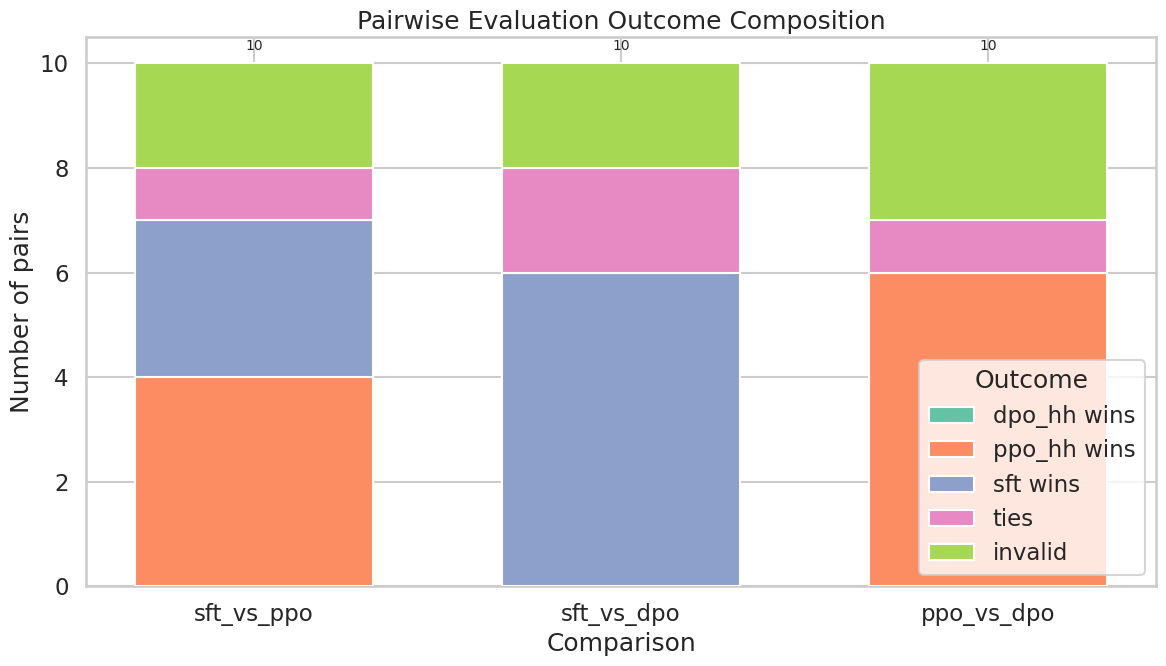

'Save the figure'

In [6]:
"""draw Plot 2"""
fig, ax = plt.subplots(figsize=(12, 7))

comp_palette = sns.color_palette("Set2", n_colors=len(ordered_cols))
color_lookup = dict(zip(ordered_cols, comp_palette))

bottom = [0] * len(pivot_df.index)
x = range(len(pivot_df.index))

for col in ordered_cols:
    values = pivot_df[col].tolist()
    ax.bar(
        x,
        values,
        bottom=bottom,
        label=col,
        color=color_lookup[col],
        width=0.65,
        zorder=3,
    )
    bottom = [b + v for b, v in zip(bottom, values)]

totals = pivot_df.sum(axis=1).tolist()
for xi, total in zip(x, totals):
    ax.text(xi, total + 0.2, str(total), ha="center", va="bottom", fontsize=10)

ax.set_title("Pairwise Evaluation Outcome Composition")
ax.set_xlabel("Comparison")
ax.set_ylabel("Number of pairs")
ax.set_xticks(list(x))
ax.set_xticklabels(pivot_df.index.tolist())
ax.legend(title="Outcome", frameon=True)

fig.tight_layout()
plt.show()

"""Save the figure"""
# fig.savefig(OUT_DIR / "pairwise_outcome_composition.png", dpi=300, bbox_inches="tight")
# fig.savefig(OUT_DIR / "pairwise_outcome_composition.pdf", bbox_inches="tight")
# print(OUT_DIR / "pairwise_outcome_composition.png")
# print(OUT_DIR / "pairwise_outcome_composition.pdf")


In [7]:
"""Save the data table"""
df.to_csv(OUT_DIR / "pairwise_win_rates_table.csv", index=False)
print(OUT_DIR / "pairwise_win_rates_table.csv")

/mnt/Data2/zfang/rlhf_assignment/outputs/pairwise_compare/plots/pairwise_win_rates_table.csv


### SUMMARY



In our pilot blind pairwise evaluation, PPO-HH achieved the strongest preference performance, SFT ranked second, and DPO-HH ranked lowest. This indicates that preference optimization did not automatically improve model quality in our setting. In particular, DPO-HH appears to have degraded response quality and safety relative to the SFT baseline. Because the evaluation set was small, these findings should be treated as preliminary.

PPO vs SFT: PPO slightly better

SFT vs DPO: SFT clearly better

PPO vs DPO: PPO clearly better


SFT can beat DPO when:

DPO data is narrow or noisy,

formatting is imperfect,

hyperparameters are not ideal,

or DPO over-specializes away from general assistant quality.